# **RetailIQ**


# **Objective(Problem statment)**

1. Uncover revenue patterns, customer behavior, and regional sales performance
2. Identify high-performing product categories
3. Analyze key customer segments contributing to revenue
4. Evaluate city-wise sales distribution
5. Explore time-based purchasing trends (day/time analysis)
6. Assess customer satisfaction using ratings


# **Outcome**

The analysis helps derive actionable business insights for improving sales strategy, customer targeting, and operational efficiency.

# **Domain**
**Retail / E-commerce**

#**Dataset Information**

**Source:** OpenML <font color="blue"><u> **https://www.openml.org/search?type=data&status=active&id=43605&sort=runs**</font></u>

**Year / Timeline:** Data collected during January 2018 to March 2018

**Dataset description:** The dataset contains **1000 observations and 13 features** rlated to sales.

**Dataset Column/features Description:**

* **Invoice_ID**- Billing ID

* **Date** - Purchase Date

* **Time** - Purchase Time

* **Gender** - Customer's Gender

* **Location** - Customer's location

* **City** - Customer's city

* **Member** -  Customer's Membership status

* **Category** - Product Category Purchased

* **Price** - Price of the product

* **Quantity** - Number of units purchased

* **Total** - Total amount spent by the customer ( quantity * price )

* **Payment** - Mode of Payment

* **Rating** - Customer Rating

## **Problem Definition and Dataset Selection**

In [ ]:
# Importing Libraries and loading dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("https://raw.githubusercontent.com/maha0210ms-hue/Main-Project/refs/heads/main/Retail_Transaction_Dataset.csv")

In [ ]:
# Exploratory Data Analysis

df.head()

,Invoice_ID,Date,Time,Gender,Location,City,Member,Category,Price,Quantity,Total,Payment,Rating
0,460489604,1/25/2018,16:46,Male,Brookfield,NewYork,Yes,Groceries,30,1,30,Cash,2
1,471006167,3/19/2018,16:48,Female,Water tower,Chicago,Yes,Fashion,35,5,175,Card,3
2,411909258,2/25/2018,13:33,Male,Water tower,Chicago,No,Clothing,57,2,114,Cash,5
3,487313402,1/22/2018,13:38,Female,Park lane,Dallas,Yes,Sporting,89,4,356,Gpay,1
4,197763430,2/18/2018,15:31,Female,Park lane,Dallas,No,Books,82,5,410,Cash,4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Invoice_ID  1000 non-null   int64 
 1   Date        1000 non-null   object
 2   Time        1000 non-null   object
 3   Gender      1000 non-null   object
 4   Location    1000 non-null   object
 5   City        1000 non-null   object
 6   Member      1000 non-null   object
 7   Category    1000 non-null   object
 8   Price       1000 non-null   int64 
 9   Quantity    1000 non-null   int64 
 10  Total       1000 non-null   int64 
 11  Payment     1000 non-null   object
 12  Rating      1000 non-null   int64 
dtypes: int64(5), object(8)
memory usage: 101.7+ KB


In [ ]:
df.describe()

,Invoice_ID,Price,Quantity,Total,Rating
count,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000
mean,4.944931e+08,51.112000,4.059000,207.788000,2.972000
std,2.870685e+08,28.912443,2.027716,165.626167,1.428025
min,6.614050e+05,1.000000,1.000000,1.000000,1.000000
25%,2.508726e+08,27.000000,2.000000,72.000000,2.000000
50%,4.781491e+08,51.000000,4.000000,174.000000,3.000000
75%,7.459453e+08,76.250000,6.000000,304.500000,4.000000
max,9.996658e+08,100.000000,7.000000,693.000000,5.000000


In [ ]:
df.shape

(1000, 13)

In [ ]:
df.isnull().sum()

,0
Invoice_ID,0
Date,0
Time,0
Gender,0
Location,0
City,0
Member,0
Category,0
Price,0
Quantity,0


In [ ]:
df.duplicated(subset=['Invoice_ID']).sum()

np.int64(0)

**Data Cleaning and Pre-processing**

Dataset doesn't have null values or duplicates to be treated.

In [ ]:
# Renaming Member column to Is_Member? , Total to Total_Amountfor better understanding

df = df.rename(columns={'Member':'Is_Member?','Total':'Total_Amount'})
df

,Invoice_ID,Date,Time,Gender,Location,City,Is_Member?,Category,Price,Quantity,Total_Amount,Payment,Rating
0,460489604,1/25/2018,16:46,Male,Brookfield,NewYork,Yes,Groceries,30,1,30,Cash,2
1,471006167,3/19/2018,16:48,Female,Water tower,Chicago,Yes,Fashion,35,5,175,Card,3
2,411909258,2/25/2018,13:33,Male,Water tower,Chicago,No,Clothing,57,2,114,Cash,5
3,487313402,1/22/2018,13:38,Female,Park lane,Dallas,Yes,Sporting,89,4,356,Gpay,1
4,197763430,2/18/2018,15:31,Female,Park lane,Dallas,No,Books,82,5,410,Cash,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,818829599,3/26/2018,11:19,Male,Park lane,Dallas,No,Groceries,31,4,124,Card,3
996,556589713,2/20/2018,17:17,Male,Water tower,Chicago,Yes,Groceries,3,5,15,Gpay,3
997,82324424,2/6/2018,11:44,Male,Brookfield,NewYork,No,Clothing,71,5,355,Card,3
998,783661702,1/29/2018,15:44,Female,Brookfield,NewYork,No,Clothing,89,7,623,Cash,5


In [ ]:
# Data type conversion

df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
df['Time'] = pd.to_datetime(df['Time'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Invoice_ID    1000 non-null   int64         
 1   Date          1000 non-null   datetime64[ns]
 2   Time          1000 non-null   datetime64[ns]
 3   Gender        1000 non-null   object        
 4   Location      1000 non-null   object        
 5   City          1000 non-null   object        
 6   Is_Member?    1000 non-null   object        
 7   Category      1000 non-null   object        
 8   Price         1000 non-null   int64         
 9   Quantity      1000 non-null   int64         
 10  Total_Amount  1000 non-null   int64         
 11  Payment       1000 non-null   object        
 12  Rating        1000 non-null   int64         
dtypes: datetime64[ns](2), int64(5), object(6)
memory usage: 101.7+ KB


In [ ]:
categorical_col = ['Gender','Location','City','Is_Member?','Category','Payment']
for col in categorical_col:
  print(f'Unique values in {col}')
  print(df[col].unique())


Unique values in Gender
['Male' 'Female']
Unique values in Location
['Brookfield' 'Water tower' 'Park lane']
Unique values in City
['NewYork' 'Chicago' 'Dallas']
Unique values in Is_Member?
['Yes' 'No']
Unique values in Category
['Groceries' 'Fashion' 'Clothing' 'Sporting' 'Books' 'Furniture']
Unique values in Payment
['Cash' 'Card' 'Gpay']


In [ ]:
# Treating Location column with title() to improve readability

df['Location'] = df['Location'].str.title()

In [ ]:
df['Location'].unique()

array(['Brookfield', 'Water Tower', 'Park Lane'], dtype=object)

In [ ]:
# converting datatype of price and total to float

price_col = ['Price','Total_Amount']
for col in price_col:
  df[col]=df[col].astype(float)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Invoice_ID    1000 non-null   int64         
 1   Date          1000 non-null   datetime64[ns]
 2   Time          1000 non-null   datetime64[ns]
 3   Gender        1000 non-null   object        
 4   Location      1000 non-null   object        
 5   City          1000 non-null   object        
 6   Is_Member?    1000 non-null   object        
 7   Category      1000 non-null   object        
 8   Price         1000 non-null   float64       
 9   Quantity      1000 non-null   int64         
 10  Total_Amount  1000 non-null   float64       
 11  Payment       1000 non-null   object        
 12  Rating        1000 non-null   int64         
dtypes: datetime64[ns](2), float64(2), int64(3), object(6)
memory usage: 101.7+ KB


In [ ]:
df

,Invoice_ID,Date,Time,Gender,Location,City,Is_Member?,Category,Price,Quantity,Total_Amount,Payment,Rating
0,460489604,2018-01-25,2026-06-11 16:46:00,Male,Brookfield,NewYork,Yes,Groceries,30.0,1,30.0,Cash,2
1,471006167,2018-03-19,2026-06-11 16:48:00,Female,Water Tower,Chicago,Yes,Fashion,35.0,5,175.0,Card,3
2,411909258,2018-02-25,2026-06-11 13:33:00,Male,Water Tower,Chicago,No,Clothing,57.0,2,114.0,Cash,5
3,487313402,2018-01-22,2026-06-11 13:38:00,Female,Park Lane,Dallas,Yes,Sporting,89.0,4,356.0,Gpay,1
4,197763430,2018-02-18,2026-06-11 15:31:00,Female,Park Lane,Dallas,No,Books,82.0,5,410.0,Cash,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,818829599,2018-03-26,2026-06-11 11:19:00,Male,Park Lane,Dallas,No,Groceries,31.0,4,124.0,Card,3
996,556589713,2018-02-20,2026-06-11 17:17:00,Male,Water Tower,Chicago,Yes,Groceries,3.0,5,15.0,Gpay,3
997,82324424,2018-02-06,2026-06-11 11:44:00,Male,Brookfield,NewYork,No,Clothing,71.0,5,355.0,Card,3
998,783661702,2018-01-29,2026-06-11 15:44:00,Female,Brookfield,NewYork,No,Clothing,89.0,7,623.0,Cash,5


In [ ]:
print(df['Total_Amount'].max())
print(df['Total_Amount'].min())

693.0
1.0


In [ ]:
# Feature transformations

date_index = df.columns.get_loc('Date') # to get the index postion of date

df.insert(
    date_index + 1,
    'Day',
    df['Date'].dt.day_name()
)

df.insert(
    date_index + 2,
    'Month',
    df['Date'].dt.month_name()
)

In [ ]:
total_index = df.columns.get_loc('Total_Amount')

df.insert(
    total_index + 1,
    'Sales_Category',
    pd.cut(df['Total_Amount'],
           bins=[0,200,400,700],
           labels=['Low','Medium','High'])
)

In [ ]:
df

,Invoice_ID,Date,Day,Month,Time,Gender,Location,City,Is_Member?,Category,Price,Quantity,Total_Amount,Sales_Category,Payment,Rating
0,460489604,2018-01-25,Thursday,January,2026-06-10 16:46:00,Male,Brookfield,NewYork,Yes,Groceries,30.0,1,30.0,Low,Cash,2
1,471006167,2018-03-19,Monday,March,2026-06-10 16:48:00,Female,Water Tower,Chicago,Yes,Fashion,35.0,5,175.0,Low,Card,3
2,411909258,2018-02-25,Sunday,February,2026-06-10 13:33:00,Male,Water Tower,Chicago,No,Clothing,57.0,2,114.0,Low,Cash,5
3,487313402,2018-01-22,Monday,January,2026-06-10 13:38:00,Female,Park Lane,Dallas,Yes,Sporting,89.0,4,356.0,Medium,Gpay,1
4,197763430,2018-02-18,Sunday,February,2026-06-10 15:31:00,Female,Park Lane,Dallas,No,Books,82.0,5,410.0,High,Cash,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,818829599,2018-03-26,Monday,March,2026-06-10 11:19:00,Male,Park Lane,Dallas,No,Groceries,31.0,4,124.0,Low,Card,3
996,556589713,2018-02-20,Tuesday,February,2026-06-10 17:17:00,Male,Water Tower,Chicago,Yes,Groceries,3.0,5,15.0,Low,Gpay,3
997,82324424,2018-02-06,Tuesday,February,2026-06-10 11:44:00,Male,Brookfield,NewYork,No,Clothing,71.0,5,355.0,Medium,Card,3
998,783661702,2018-01-29,Monday,January,2026-06-10 15:44:00,Female,Brookfield,NewYork,No,Clothing,89.0,7,623.0,High,Cash,5


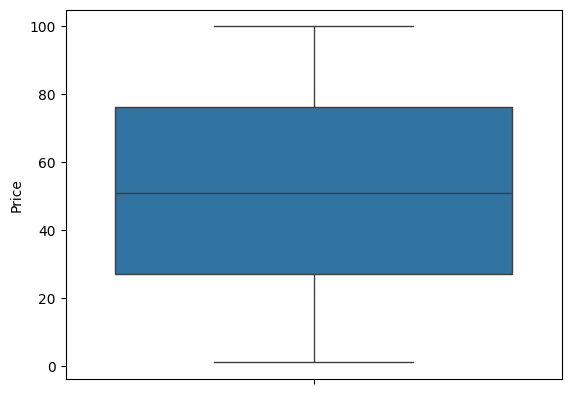

In [ ]:
# identifying outliers

sns.boxplot(df['Price'])
plt.show()

In [ ]:
df['Price'].skew()

np.float64(-0.059729278747855954)

* The data is fairly balanced around the center.
* There is no significant skewness.

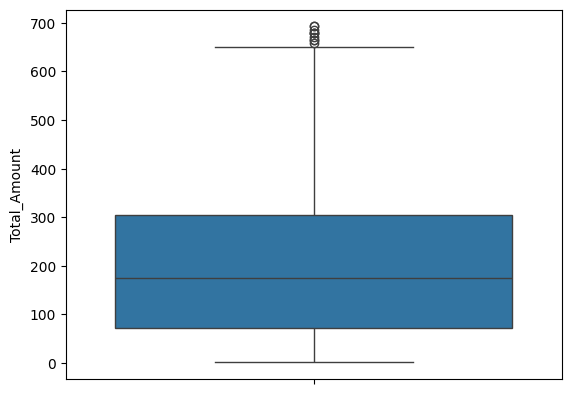

In [ ]:
sns.boxplot(df['Total_Amount'])
plt.show()

In [ ]:
df['Total_Amount'].skew()

np.float64(0.8775558062764715)

* Most values are concentrated on the lower side.
* A smaller number of high values pull the distribution to the right.

**Outliers in Total_Amount is reasonable so treating outliers is not required**

In [ ]:
df.to_csv('Retail_Transaction_Dataset_cleaned.csv', index=False)

In [ ]:
from google.colab import files
files.download('Retail_Transaction_Dataset_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## EDA and Visualizations


**Uncover revenue patterns, customer behavior, and regional sales performance**

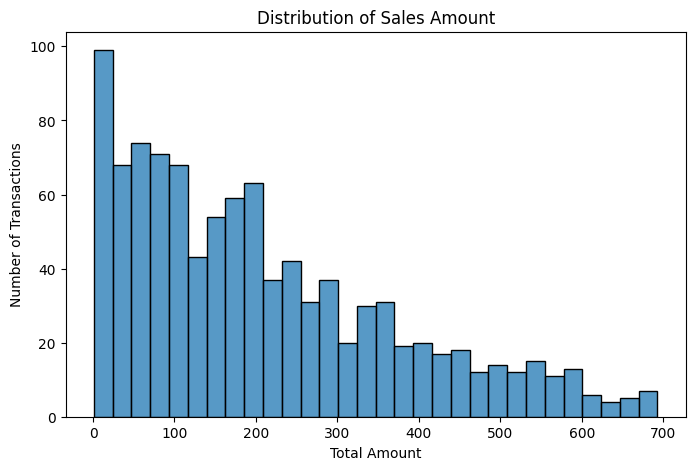

In [ ]:
# Revenue pattern
plt.figure(figsize=(8,5))
sns.histplot(df['Total_Amount'],bins=30)
plt.title('Distribution of Sales Amount')
plt.xlabel('Total Amount')
plt.ylabel('Number of Transactions')
plt.show()

## Distribution of Sales Amount

* The chart shows how the Total Amount is distributed across all transactions.
* X-Axis represents the Total Amount of the transaction.
* Y-Axis represents the Number of transactions.

* Most of the transactions happened between 0 to 300.
* Very few transactions happened between 600 to 700.

* Used Total_Amount Feature

* Most Customers make low-to-medium value purchases.
* Only Small group of customers make high value purchases.
* The distribution is right skewed.

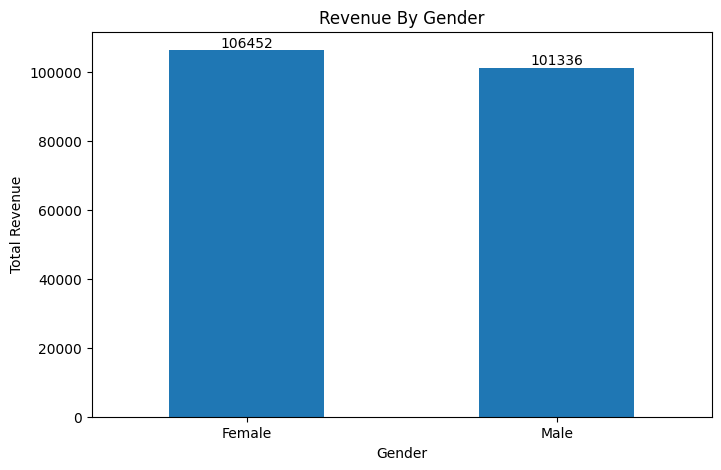

In [ ]:
# customer behavior - Based On Gender
gender_revenue = df.groupby('Gender')['Total_Amount'].sum()
plt.figure(figsize=(8,5))
ax = gender_revenue.plot(kind='bar')
plt.title('Revenue By Gender')
plt.xticks(rotation=0)
plt.ylabel('Total Revenue')
ax.bar_label(ax.containers[0])
plt.show()

## Revenue By Gender

* The chart shows the total revenue contribution by gender.
* Female customers generated ₹106,452 in revenue, while male customers generated ₹101,336.
* Female customers contributed slightly more revenue than male customers; * however, the difference is relatively small.
* **Features Used:** Gender, Total_Amount.
* This analysis helps understand revenue contribution across customer segments.

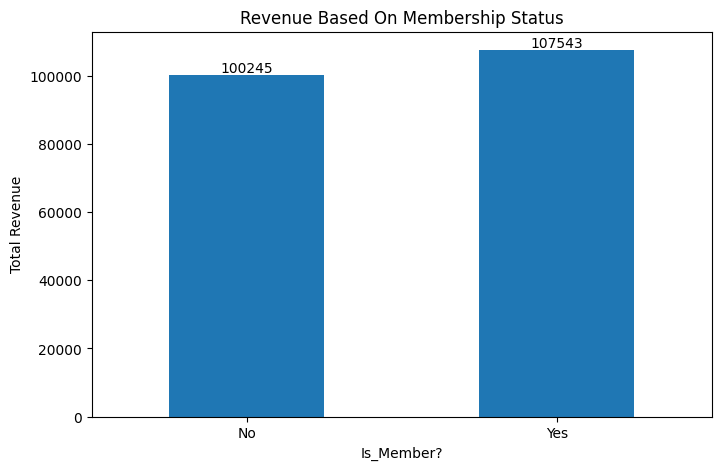

In [ ]:
# customer behavior - Based on Membership
member_revenue = df.groupby('Is_Member?')['Total_Amount'].sum()
plt.figure(figsize=(8,5))
ax = member_revenue.plot(kind='bar')
plt.title('Revenue Based On Membership Status')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
ax.bar_label(ax.containers[0])
plt.show()

## Revenue Based On Membership Status

* The chart compares the revenue contribution of Members and Non-Members.
* Members generated ₹107,543 in revenue, while Non-Members generated ₹100,245.
* Members contributed slightly more revenue than Non-Members, although the difference is relatively small.
* **Features Used:** Is_Member?, Total_Amount.
* This analysis helps evaluate the impact of membership status on overall revenue generation.

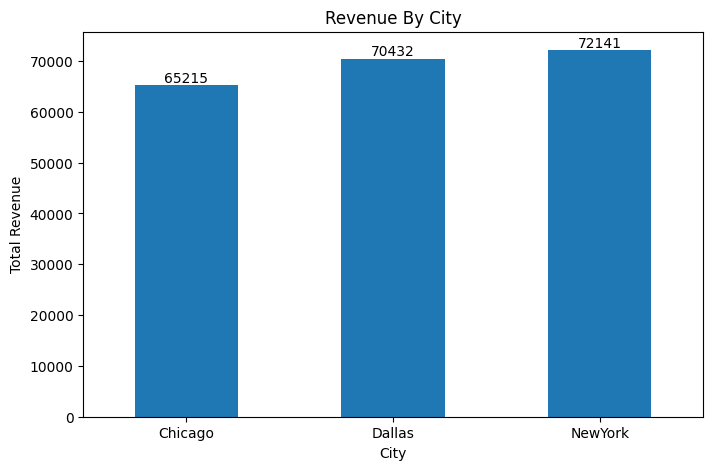

In [ ]:
# regional sales performance
city_revenue = df.groupby('City')['Total_Amount'].sum()
plt.figure(figsize=(8,5))
ax = city_revenue.plot(kind='bar')
plt.title('Revenue By City')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
ax.bar_label(ax.containers[0])
plt.show()

## Revenue By City

* The chart compares the revenue contribution across different cities.
* **New York** generated the highest revenue, making it the top-performing city.
* **Chicago** generated the lowest revenue among all cities.
* Revenue contributions from **New York** and **Dallas** are relatively close, indicating strong sales performance in both cities.
* **Features Used:** City, Total_Amount.
* This analysis helps identify high-performing and low-performing cities based on revenue generation.

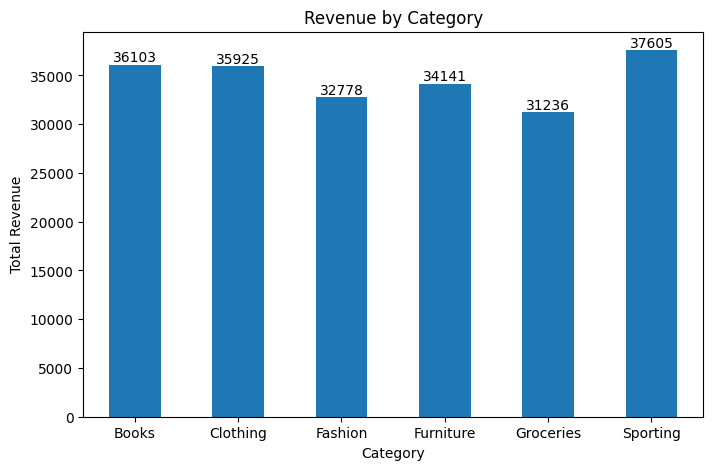

In [ ]:
# Identify high-performing product categories
category_sales = df.groupby('Category')['Total_Amount'].sum()
plt.figure(figsize=(8,5))
ax = category_sales.plot(kind='bar')
plt.ylabel('Total Revenue')
plt.title('Revenue by Category')
plt.xticks(rotation=0)
ax.bar_label(ax.containers[0])
plt.show()

## Revenue By Category
* The chart compares the revenue contribution of different product categories.
* **Sporting** is the highest revenue-generating category, indicating strong customer demand and sales performance.
* **Groceries** is the lowest revenue-generating category among all categories.
* **Features Used:** Category, Total_Amount.
* This analysis helps identify the categories that contribute the most and least to overall revenue.

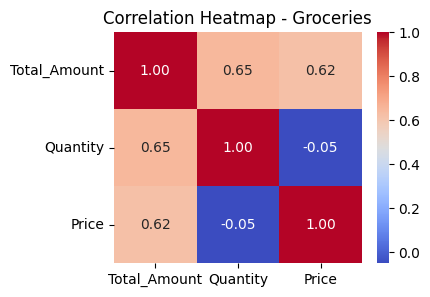

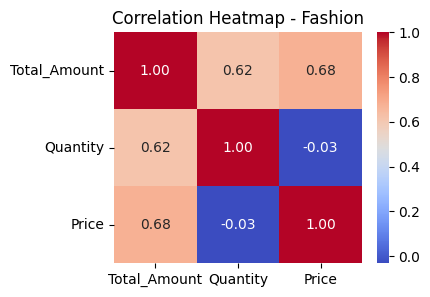

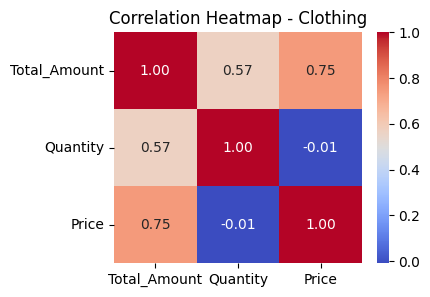

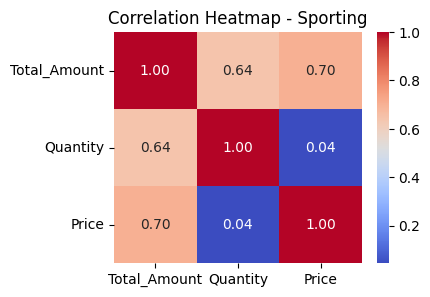

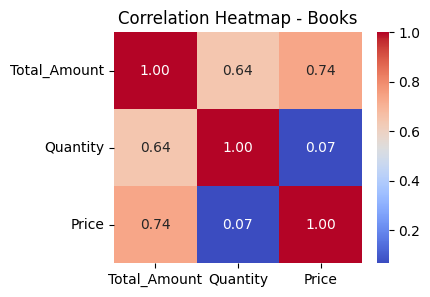

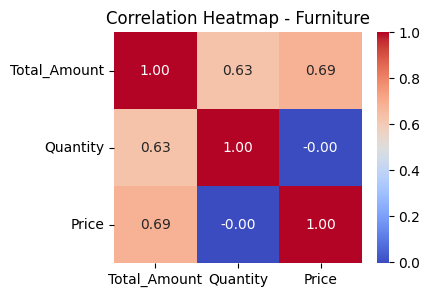

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

for category in df['Category'].unique():

    category_df = df[df['Category'] == category]

    corr_matrix = category_df[['Total_Amount', 'Quantity', 'Price']].corr()

    plt.figure(figsize=(4,3))
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap='coolwarm',
        fmt='.2f'
    )

    plt.title(f'Correlation Heatmap - {category}')
    plt.show()

## Correlation Heatmap by Category
* The heatmap visualizes the correlation between Total Amount, Quantity, and Price across different Categories.
* Revenue **(Total Amount)** in all categories is positively influenced by both Price and Quantity, indicating that higher sales volumes and higher-priced products contribute to increased revenue.
* The correlation between Quantity and Price is generally weak, suggesting that customers do not significantly reduce their purchases when product prices are higher.
* **Features Used:** Total_Amount, Quantity, Price, Category.
* This analysis helps identify the key factors driving revenue within each category and understand the relationship between pricing and purchasing behavior.


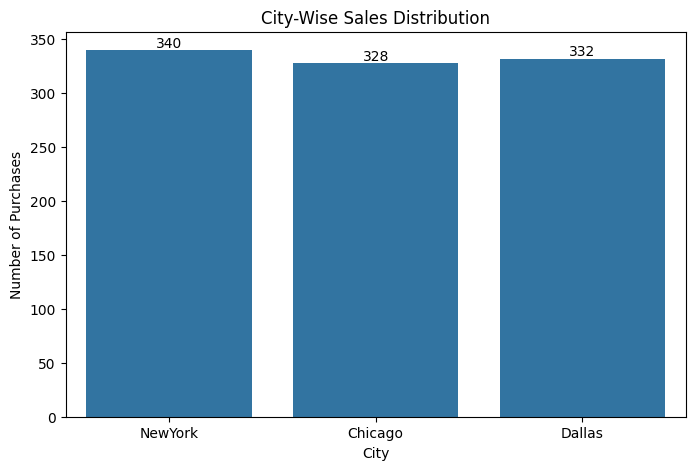

In [ ]:
# Evaluate city-wise sales distribution

plt.figure(figsize=(8,5))
ax = sns.countplot(data=df,x='City')
plt.ylabel('Number of Purchases')
plt.title('City-Wise Sales Distribution')
ax.bar_label(ax.containers[0])
plt.show()

## City-Wise Sales distribution
* The chart shows the number of transactions across different cities.
* **New York** recorded the highest number of transactions **(340)**, indicating strong customer activity.
* Transaction counts vary across cities, highlighting differences in customer purchasing behavior.
* The difference in transaction volume between cities is not substantial, indicating a fairly balanced distribution of customer purchases across regions.
* **Feature Used:** City.
* This analysis helps identify cities with the highest and lowest transaction volumes.

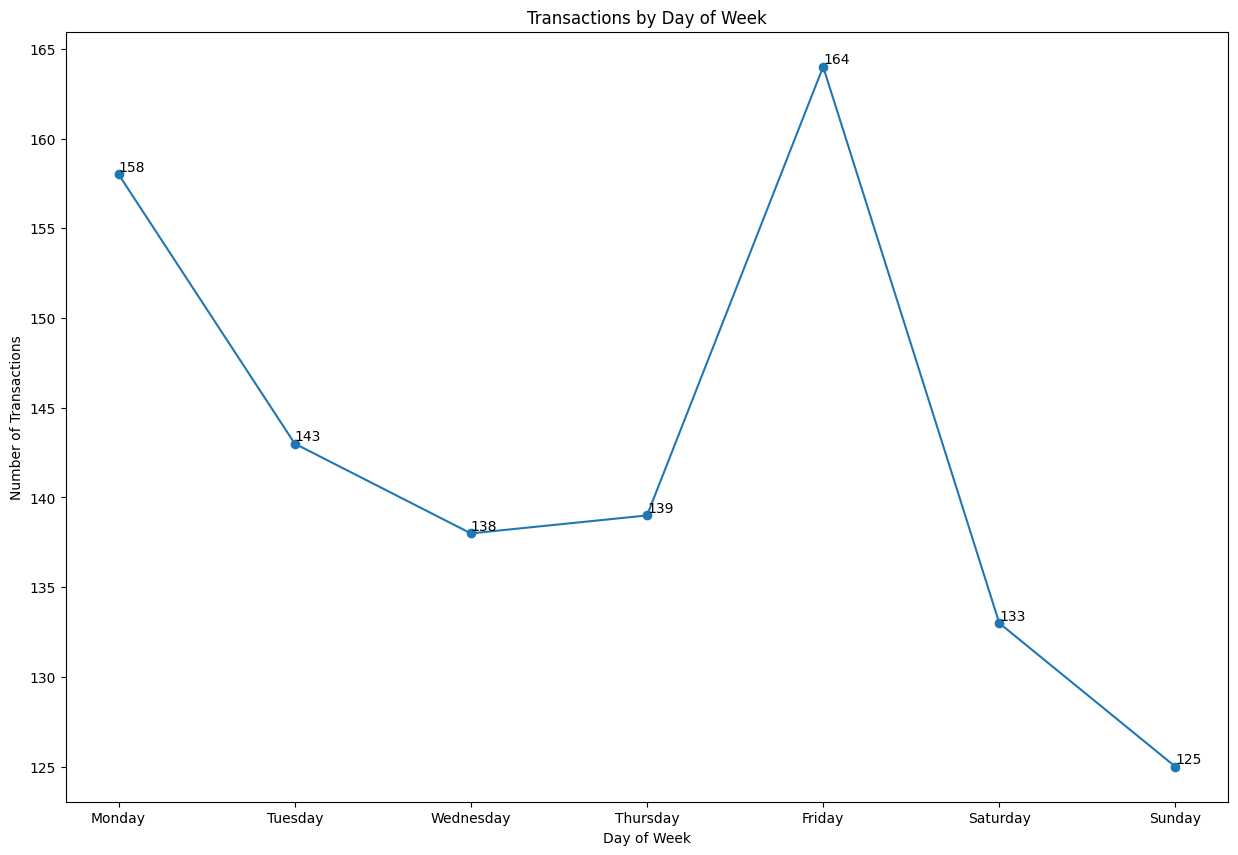

In [ ]:
# Day-based purchasing trends (day/time analysis)

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

transactions_by_day_of_week = df['Day'].value_counts().reindex(day_order)

plt.figure(figsize=(8,5))

plt.plot(day_order, transactions_by_day_of_week.values, marker='o')

for i, v in enumerate(transactions_by_day_of_week):
    plt.text(i, v, str(v), ha='left', va='bottom')

plt.title('Transactions by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Transactions')
plt.show()

## Day-based purchasing trends
* This chart shows the trend of transactions across each day of the week.
* Friday records the highest number of transactions (164), indicating it is the busiest shopping day.
* **Feature Used:** Day (derived from Date)
* This analysis helps identify peak and low-traffic days, which is useful for **staff allocation, inventory planning, and promotional strategies**.


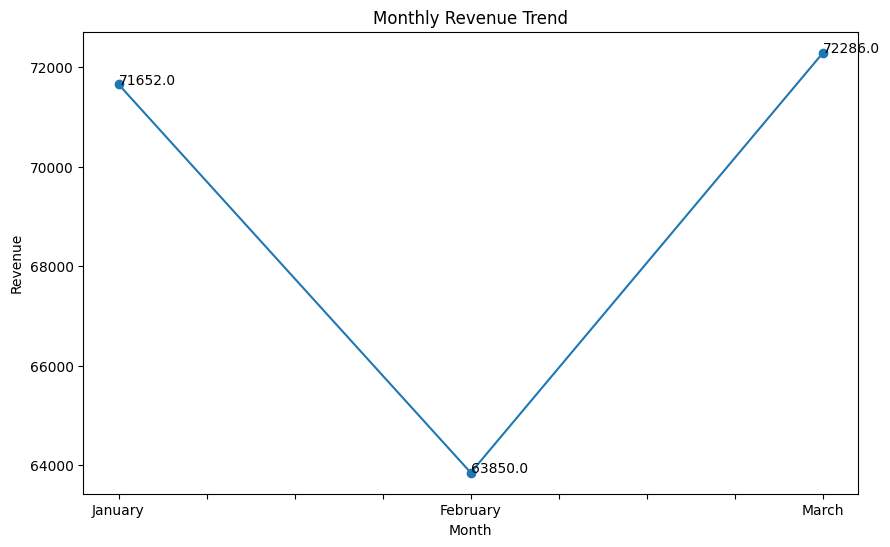

In [ ]:
monthly_revenue = df.groupby('Month')['Total_Amount'].sum()

# Order months correctly
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly_revenue = monthly_revenue.reindex(month_order)

plt.figure(figsize=(10,6))
ax = monthly_revenue.plot(marker='o')
for i,v in enumerate(monthly_revenue):
  plt.text(i, v,str(v))
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

## Monthly Revenue Trend
* The chart shows the total revenue generated each month.
* Revenue was ₹71,652 in January.
* Revenue decreased to ₹63,850 in February, the lowest among the three months.
* Revenue increased significantly to ₹72,286 in March, making it the highest revenue-generating month.
* **Feature Used:** Month,Total_Amount
* It helps identify changes in sales performance over time and highlights peak and low-performing months.

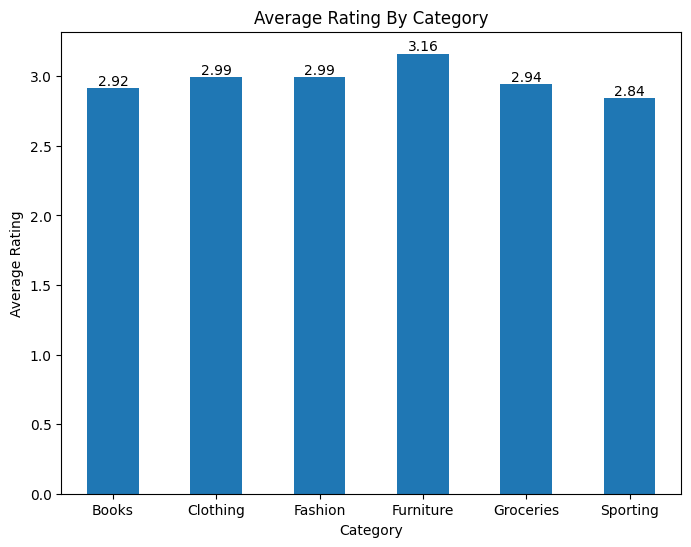

In [ ]:
# Assess customer satisfaction by Rating

category_rating = df.groupby('Category')['Rating'].mean()
plt.figure(figsize=(8,6))
ax = category_rating.plot(kind = 'bar')
ax.bar_label(ax.containers[0],fmt='%.2f')
plt.ylabel('Average Rating')
plt.title('Average Rating By Category')
plt.xticks(rotation=0)
plt.show()

## Average Rating by category
* The chart compares the average customer rating across different product categories.
* Furniture has the highest average rating (3.16), indicating relatively better customer satisfaction.
* Sporting has the lowest average rating (2.84).
* The remaining categories (Books, Clothing, Fashion, and Groceries) have average ratings between 2.92 and 2.99.
* The difference between categories is relatively small, with all average ratings clustered around 3 out of 5.
* **Feature Used:** Category,Rating
* It helps identify which categories have the highest and lowest customer satisfaction.


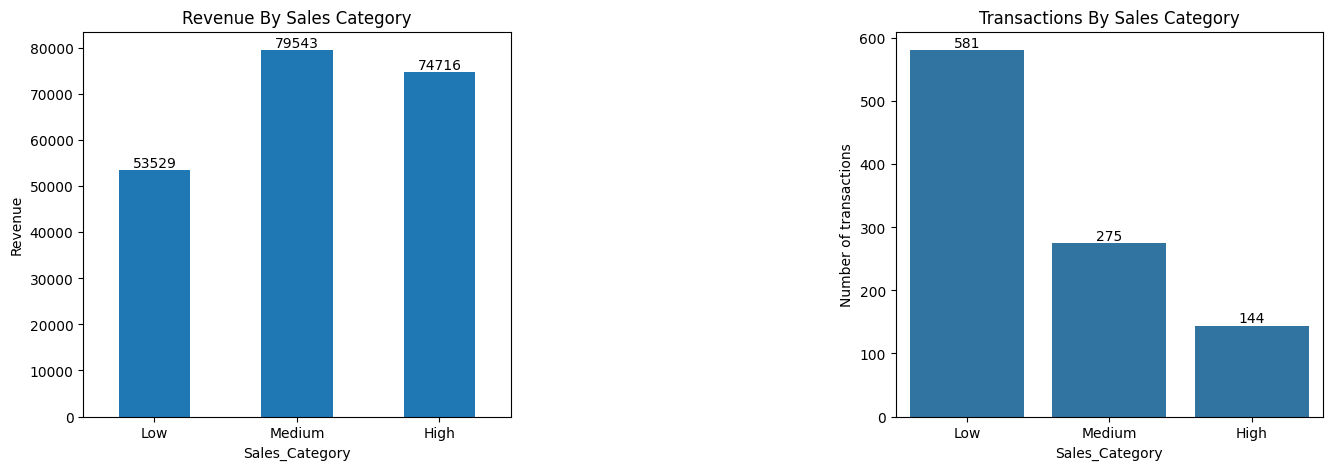

In [ ]:
# Comparison of Revenue and Transactions by sales category

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sales_rev = df.groupby('Sales_Category',observed=False)['Total_Amount'].sum()
ax = sales_rev.plot(kind='bar',ax=axes[0])
ax.bar_label(ax.containers[0])
axes[0].tick_params(axis='x', rotation=0)
axes[0].set_ylabel('Revenue')
axes[0].set_title('Revenue By Sales Category')

ax = sns.countplot(data=df,x='Sales_Category',ax=axes[1])
ax.bar_label(ax.containers[0])
axes[1].set_ylabel('Number of transactions')
axes[1].set_title('Transactions By Sales Category')
plt.subplots_adjust(wspace=0.9)
plt.show()

## Comparison of Revenue and Transactions by sales category
* The charts compare the revenue generated and the number of transactions across different sales categories.
* The Medium Sales Category generates the highest revenue, despite having fewer transactions than the Low Sales Category.
* This suggests that customers in the Medium Sales Category tend to purchase higher quantities or have a higher average transaction value.
* The Low Sales Category records the highest number of transactions but contributes less revenue compared to the Medium Sales Category.
* **Features Used:** Sales_Category, Total_Amount, Transaction_ID.
* This analysis helps identify which sales segment contributes most to revenue and how transaction volume differs across sales categories.

## **Steps to Download your cleaned data for dashboard creation using Power BI**


In [ ]:
import pandas as pd
df.to_csv('Retail_Transaction_Dataset_cleaned.csv', index=False)

## Documentation, Insights and Presentation



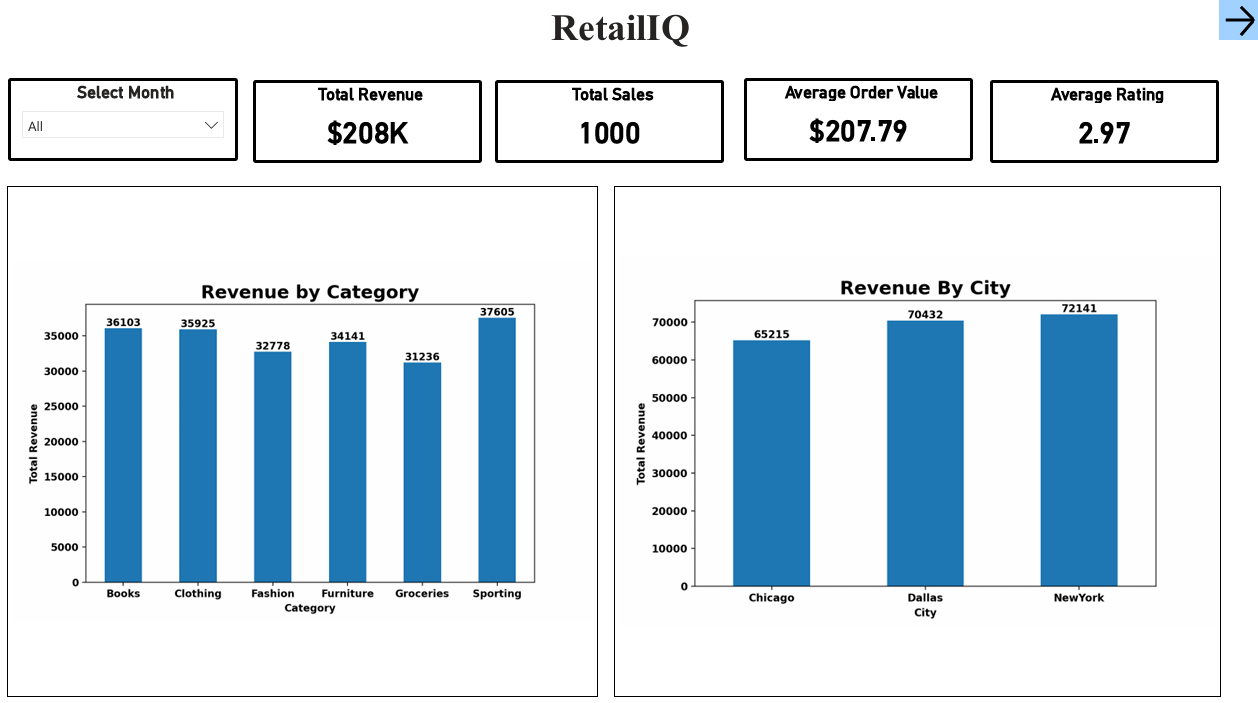

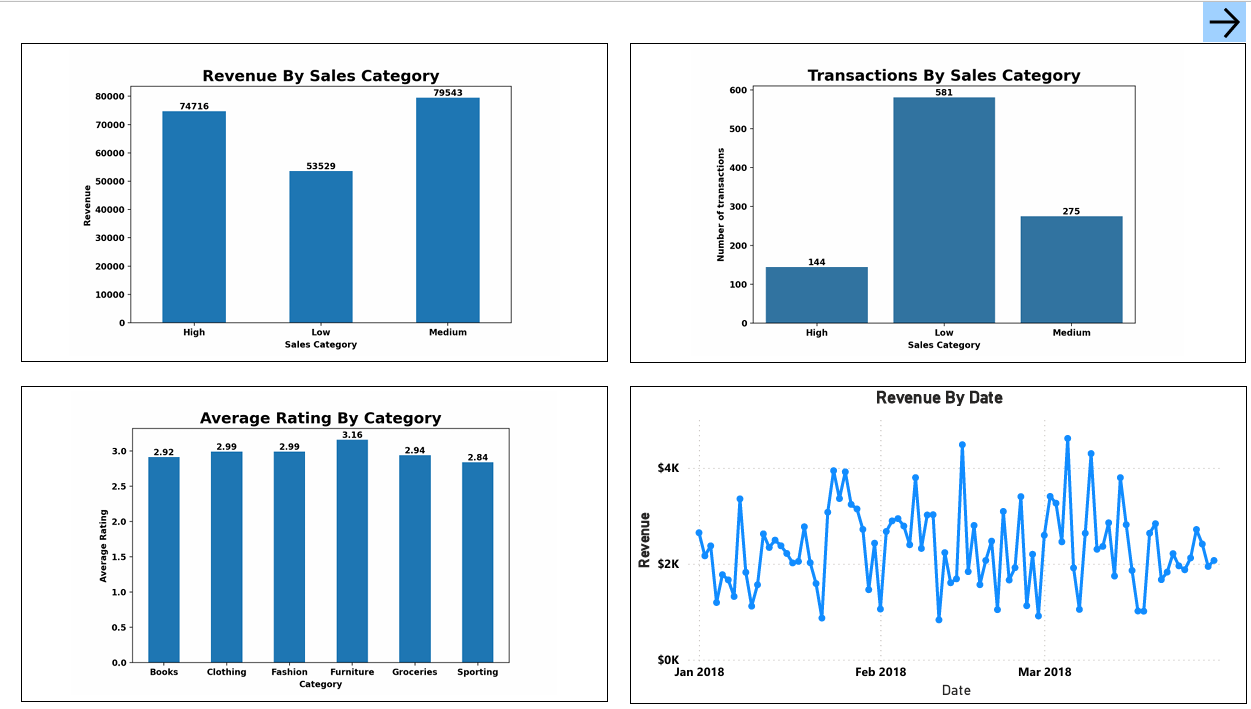

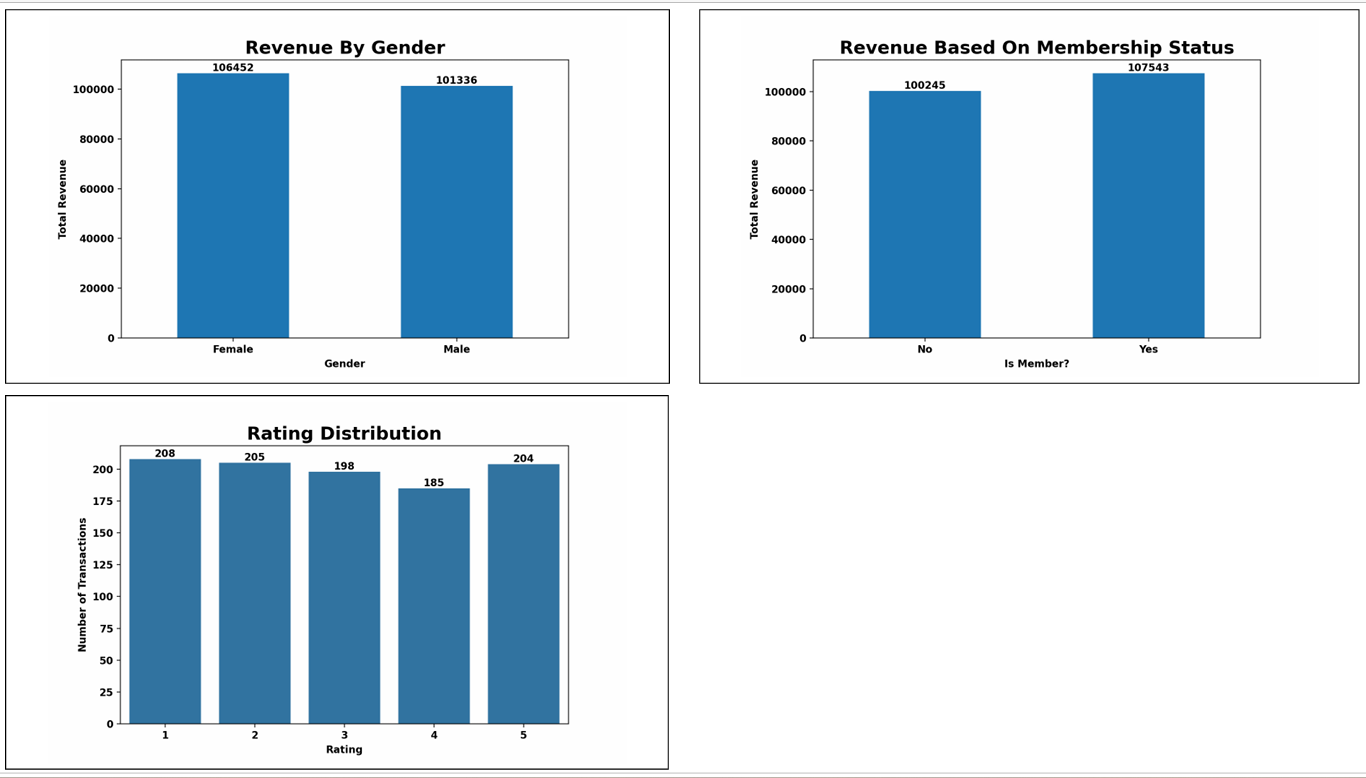

## Documentation

https://drive.google.com/drive/folders/1GwxFUQiTtqBMdCseaSnkR5LCaDQv0xsK?usp=sharing

## Insights

* The dataset reveals that most transactions are low-to-medium value purchases, with a few high-value transactions contributing significantly to overall revenue. These outliers are likely driven by larger quantities purchased rather than higher product prices.
* **Sporting** emerged as the highest revenue-generating category, while **Groceries** contributed the least revenue. This indicates strong customer demand for Sporting products and potential opportunities to improve the performance of lower-revenue categories.
* Revenue contribution is fairly balanced across customer segments. **Female customers and Members** generated slightly higher revenue than **Male customers and Non-Members**, but the differences are relatively small, suggesting similar spending behavior across these groups.
* Regional sales performance is well distributed across cities. New York recorded the highest revenue and transaction count; however, the differences between cities are not substantial, indicating that the business is not heavily dependent on a single market.
* Time-based analysis showed fluctuations in monthly revenue, with sales declining in February and recovering strongly in March, which became the highest revenue-generating month. This highlights the importance of monitoring seasonal and time-based purchasing trends for planning purposes.
* Customer satisfaction analysis revealed that ratings are fairly evenly distributed across all rating levels, indicating mixed customer sentiment. Furniture received the highest average rating, while Sporting received the lowest, suggesting potential opportunities to improve customer experience within certain categories.
* Overall, the business demonstrates a diversified customer base, balanced regional performance, and stable revenue generation. Focusing on high-performing categories, improving lower-rated products, strengthening customer loyalty programs, and leveraging purchasing trends can help drive future growth and enhance customer satisfaction.

## Conclusion
* RetailIQ demonstrates a healthy and diversified retail business with stable sales across cities, customer segments, and product categories.
* Sporting products are the strongest revenue driver, while Medium-value transactions contribute the largest share of revenue.
* Customer satisfaction remains moderate, with opportunities to improve high-revenue categories such as Sporting.
* The balanced regional performance reduces business risk, and steady revenue trends indicate consistent customer demand.
* By improving customer satisfaction in key categories and increasing medium-value purchases through targeted marketing strategies, the business can drive sustainable revenue growth and strengthen customer loyalty.
